<a href="https://colab.research.google.com/github/utamiu1807/uutami/blob/main/Utami_ML_Foundations_PCA_Demo_with_Credit_Card_Customers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Importing required libraries
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt

import plotly.express as px

In [17]:
# Load an CSV file
file_path = 'https://www.dropbox.com/scl/fi/1jml6i3whezn5dzarkb6a/credit_card_customers.csv?rlkey=o5yjpunceaa9vo51yyudn0qw8&st=6tcl8ivy&dl=1'
df = pd.read_csv(file_path)

df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


For PCA we will only use numeric features

In [18]:
# Load an CSV file to define 'df' before using it
import pandas as pd
file_path = 'https://www.dropbox.com/scl/fi/1jml6i3whezn5dzarkb6a/credit_card_customers.csv?rlkey=o5yjpunceaa9vo51yyudn0qw8&st=6tcl8ivy&dl=1'
df = pd.read_csv(file_path)

#create new variable "Average utilization value by dividing total transaction amount to total transaction count"
df['Avg_Utilization_Value'] = df['Total_Trans_Amt'] / df['Total_Trans_Ct']

In [19]:
candidate_features = [
    "Customer_Age",
    "Dependent_count",
    "Months_on_book",
    "Total_Relationship_Count",
    "Months_Inactive_12_mon",
    "Contacts_Count_12_mon",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
    "Avg_Utilization_Value"
]

In [20]:
X = df[candidate_features].copy()

Transform all variables into standard form

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.65405580e-01,  5.03368127e-01,  3.84620878e-01, ...,
         3.83400260e+00, -7.75882235e-01, -1.33980091e+00],
       [ 3.33570383e-01,  2.04319867e+00,  1.01071482e+00, ...,
         1.26085729e+01, -6.16275655e-01, -8.89732184e-01],
       [ 5.83058365e-01,  5.03368127e-01,  8.96451285e-03, ...,
         6.80786367e+00, -9.97154993e-01,  1.20203803e+00],
       ...,
       [-2.90149571e-01, -1.03646242e+00,  8.96451285e-03, ...,
         4.44305026e-01, -9.97154993e-01,  4.12469741e+00],
       [-2.03656544e+00, -2.66547146e-01,  8.96451285e-03, ...,
         4.10696270e-02, -9.97154993e-01,  2.75691400e+00],
       [-4.14893562e-01, -2.66547146e-01, -1.36844216e+00, ...,
        -2.65557291e-01, -3.11572183e-01,  4.02006615e+00]])

We will start by using only the first 2 leading principal components, and then explore 3 principal components and 4 principal components.

In [22]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

In [23]:
explained = pca2.explained_variance_ratio_
print("\nExplained variance ratio (PC1, PC2):", explained)
print("Cumulative explained variance:", explained.sum())


Explained variance ratio (PC1, PC2): [0.19901784 0.15209399]
Cumulative explained variance: 0.35111183464633333


In [24]:
# Loadings
loadings_2 = pd.DataFrame(
    pca2.components_.T,
    columns=["PC1", "PC2"],
    index=candidate_features
)
loadings_sorted = loadings_2.reindex(loadings_2["PC1"].abs().sort_values(ascending=False).index)

print("\nTop loadings by abs(PC1):")
print(loadings_sorted.head(10))


Top loadings by abs(PC1):
                               PC1       PC2
Total_Trans_Amt           0.498792  0.280347
Avg_Utilization_Value     0.465931  0.231601
Total_Trans_Ct            0.401388  0.298030
Avg_Open_To_Buy           0.342198 -0.459491
Credit_Limit              0.339008 -0.434171
Total_Relationship_Count -0.251043 -0.112298
Avg_Utilization_Ratio    -0.237491  0.469701
Contacts_Count_12_mon    -0.071770 -0.137787
Dependent_count           0.061011 -0.019831
Total_Ct_Chng_Q4_Q1       0.056995  0.148091


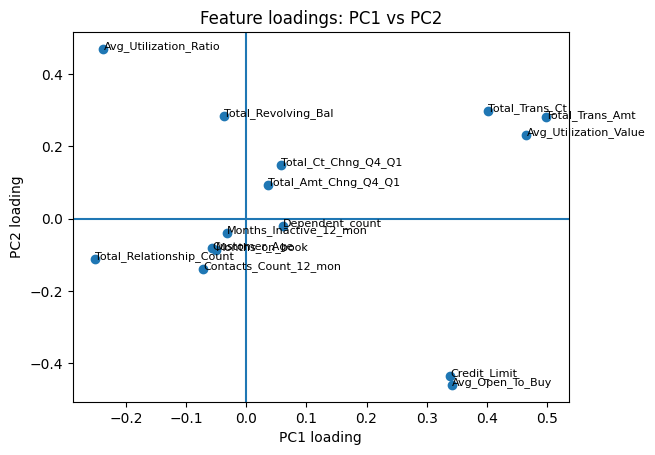

In [25]:
# Plot loadings PC1 vs PC2
plt.figure()
plt.scatter(loadings_2["PC1"], loadings_2["PC2"])
for feat in loadings_2.index:
    plt.text(loadings_2.loc[feat, "PC1"], loadings_2.loc[feat, "PC2"], feat, fontsize=8)
plt.axhline(0)
plt.axvline(0)
plt.title("Feature loadings: PC1 vs PC2")
plt.xlabel("PC1 loading")
plt.ylabel("PC2 loading")
plt.show()

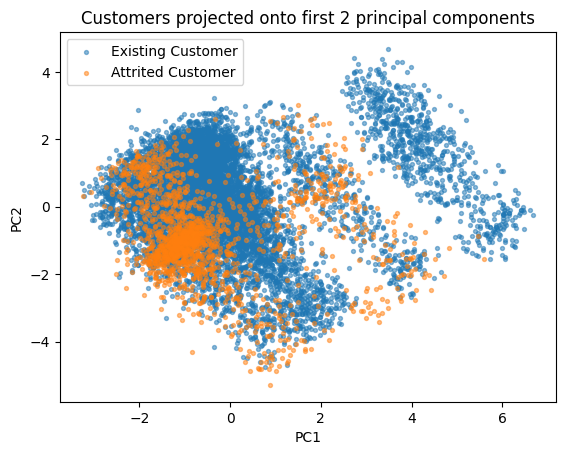

In [26]:
# Plot customers in PCA space
pca2_df = pd.DataFrame(X_pca2, columns=["PC1", "PC2"])
pca2_df["Attrition_Flag"] = df["Attrition_Flag"]

plt.figure()
for label in ["Existing Customer", "Attrited Customer"]:
    subset = pca2_df[pca2_df["Attrition_Flag"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], s=8, alpha=0.5, label=label)
plt.title("Customers projected onto first 2 principal components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()